# 03 — Anisotropic satellite quenching: SAGA + ELVES vs TNG100

Main analysis for *The Anisotropic Quenching of Satellites in Milky Way-mass Halos*. Pulls
together the SAGA and ELVES surveys and the TNG100-1 catalogs (built by
`01_tng_generate_catalogs.ipynb`) and produces the paper's Figure 1.

Steps:
1. Compute the projected azimuthal angle (theta, folded to [0, 90]; 0 = host major axis) for
   SAGA and ELVES satellites, and select the fiducial sample (SAGA Gold, within R_200c).
2. Load the TNG100 catalogs (angle + quenched precomputed for the 10^6/10^7/10^8 cuts).
3. One-sample (vs uniform) and two-sample (quenched vs star-forming) KS tests.
4. Bootstrap the quench fraction vs angle and fit it with a sinusoid `a + b*cos(2 theta)` via MCMC.
5. Compare the sinusoid to a constant with BIC/AIC, and report the amplitude significance b/sigma_b.

**Runs on a laptop** (no TNG simulation data needed) but requires internet for the SIMBAD lookup
of ELVES host position angles. TNG masses are physical M_sun (see `../docs/conventions.md`).

In [1]:
import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
from scipy import stats as st
import emcee
import matplotlib as mpl
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.table import Table, join
from astropy.coordinates import SkyCoord
from astroquery.simbad import Simbad

%matplotlib inline
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})

# which TNG catalogs to load (must match what notebook 01 wrote)
SIM      = 'TNG50'                  # 'TNG100' or 'TNG50'
REDSHIFT = 'z0'                      # 'z0' or 'z0p05'

# data locations
SAGA_DIR = '../data/saga'
ELVES_DIR = '../data/elves'
TNG_DIR  = f'../data/{SIM.lower()}/{REDSHIFT}'   # e.g. ../data/tng100/z0

# 18 angle bins over [0, 90]; ANGLE_CENTERS are the bin centers used everywhere below
N_BINS = 18
ANGLE_EDGES   = np.linspace(0, 90, N_BINS + 1)
ANGLE_CENTERS = 0.5 * (ANGLE_EDGES[:-1] + ANGLE_EDGES[1:])   # 2.5, 7.5, ..., 87.5

# plot colors
SAGA_C  = '#1f77b4'
ELVES_C = '#d62728'

## Shared helpers

`map_to_0_90` folds any azimuthal angle into [0, 90] using the four-fold symmetry of an ellipse
(major axis at 0 and 180, minor at 90 and 270); `calc_r200` converts a halo mass to R_200c.

In [2]:
def map_to_0_90(angles):
    '''Fold angles (deg) into [0, 90] using the ellipse's four-fold symmetry.'''
    a = np.mod(np.asarray(angles, dtype=float), 360.0)
    return np.where(a <= 90, a,
           np.where(a <= 180, 180 - a,
           np.where(a <= 270, a - 180, 360 - a)))

def calc_r200(mhalo_msun):
    '''R_200c and R_200m [kpc] for a halo of mass mhalo_msun [M_sun]. (from J. Zhu)'''
    import astropy.constants as const
    from astropy.cosmology import Planck18 as cosmo
    mhalo = np.asarray(mhalo_msun) * u.Msun
    delta = 200.0
    rho_c = cosmo.critical_density0
    rho_m = cosmo.critical_density0 * cosmo.Om0
    r200c = ((3 * mhalo / (4 * np.pi * delta * rho_c)) ** (1 / 3)).to(u.kpc)
    r200m = ((3 * mhalo / (4 * np.pi * delta * rho_m)) ** (1 / 3)).to(u.kpc)
    return r200c.value, r200m.value

## SAGA

Join the DR3 host (Table C1) and satellite (Table C3) tables, compute each satellite's projected
angle from its host major axis, and select the fiducial sample: **Gold** satellites within
**R_200c** of hosts that have a measured inclination/axis ratio.

In [3]:
saga_hosts = Table.read(f'{SAGA_DIR}/saga-dr3-tableC1.txt', format='ascii')
saga_sats  = Table.read(f'{SAGA_DIR}/saga-dr3-tableC3.txt', format='ascii')
# left-join host properties onto each satellite by HOSTID
saga_joined = join(saga_sats, saga_hosts, 'HOSTID', 'left',
                   uniq_col_name='{table_name}{col_name}', table_names=['', 'HOST_'])
print('SAGA hosts:', len(saga_hosts), '| satellites:', len(saga_sats))

SAGA hosts: 101 | satellites: 378


In [4]:
# host R_200c (kpc) from log halo mass, matched to each satellite
hosts_log_mhalo = np.asarray(saga_hosts['log(Mhalo)'].data)
host_mhalo_by_id = {saga_hosts['HOSTID'][i]: hosts_log_mhalo[i] for i in range(len(saga_hosts))}

sats_rhost = np.asarray(saga_sats['Rhost'].data)              # projected host distance [kpc]
r200c_of_sat = np.full(len(saga_sats), np.nan)
for i in range(len(saga_sats)):
    mh = host_mhalo_by_id.get(saga_sats['HOSTID'][i])
    if mh is not None:
        r200c_of_sat[i], _ = calc_r200(10 ** mh)

In [5]:
# projected angle of each satellite from its host's major axis (host PA from SAGA table)
saga_PA = np.zeros(len(saga_sats))
saga_quenched = np.asarray(saga_sats['quenched'].data)
host_index = {saga_hosts['HOSTID'][m]: m for m in range(len(saga_hosts))}

for n in range(len(saga_sats)):
    m = host_index.get(saga_sats['HOSTID'][n])
    if m is None:
        continue
    h_c = SkyCoord(saga_hosts['RAdeg'][m], saga_hosts['DEdeg'][m], frame='icrs', unit='deg')
    s_c = SkyCoord(saga_sats['RAdeg'][n], saga_sats['DEdeg'][n], frame='icrs', unit='deg')
    PA  = saga_hosts['PA'][m]                          # host position angle [deg]
    rel = h_c.position_angle(s_c).degree              # sky PA of satellite from host
    # orientation convention: 0 deg = host major axis, 90 deg = minor axis
    saga_PA[n] = ((90 - PA) + (90 + rel)) % 360

In [6]:
# require the host to have a measured axis ratio b/a (needed to define an orientation);
# b/a is in [0,1], so 'host_ba >= 0' keeps rows with a valid (non-masked, non-NaN) value
host_ba = np.asarray(saga_joined['HOST_ba'], dtype=float)
has_incl_ids = np.asarray(saga_joined['HOSTID'])[host_ba >= 0]

# fiducial SAGA selection: within R_200c AND Gold (sample == 1) AND host has inclination
sample = np.asarray(saga_sats['sample'])
HOSTID = np.asarray(saga_sats['HOSTID'])
saga_fiducial = (sats_rhost < r200c_of_sat) & (sample == 1) & np.isin(HOSTID, has_incl_ids)

# apply selection (use NEW names so re-running the cell is idempotent)
saga_PA_sel       = saga_PA[saga_fiducial]
saga_90           = map_to_0_90(saga_PA_sel)
saga_quenched_sel = saga_quenched[saga_fiducial]
print('SAGA fiducial: hosts =', np.unique(HOSTID[saga_fiducial]).size,
      '| satellites =', saga_fiducial.sum())

SAGA fiducial: hosts = 78 | satellites = 184


## ELVES

Host position angles come from SIMBAD. For each confirmed satellite we compute the projected
angle from the host major axis with the same convention as SAGA.

Two robustness notes (so this runs across astroquery versions and on Binder):
* the SIMBAD dimension-angle field was renamed `galdim_angle` -> `dim_angle` between versions, so
  we try both and read whichever column comes back;
* host coordinates are resolved with `SkyCoord.from_name` (returns degrees regardless of version);
* if SIMBAD has no PA for a host, we fall back to the `Position_angle` column in the local
  `Carlsten22_ELVES_host.csv`. (Both still require internet for the coordinate lookup.)

**Selection:** as in the draft, we keep only satellites **within R_200c** of their host
(`Rproj_in_Rvir? == 1`), mirroring the SAGA cut. (The original notebook applied the R_200c cut to
SAGA only; applying it to ELVES too makes the two surveys consistent.)

> NOTE: this within-R_200c ELVES sample is close to but not identical to the draft's quoted
> 26 hosts / 177 satellites; the small residual depends on the exact R_200c definition (the ELVES
> catalog's `Rproj_in_Rvir?` flag here vs. an R_200c computed from the host halo mass). Reconcile
> this against the value used in the paper if exact counts matter.

In [7]:
elves_sats  = pd.read_csv(f'{ELVES_DIR}/Carlsten22_ELVES_confirmed_sats.csv')
elves_hosts = pd.read_csv(f'{ELVES_DIR}/Carlsten22_ELVES_host.csv')
print('ELVES hosts:', len(elves_hosts), '| confirmed satellites:', len(elves_sats))

# local fallback: host name -> Position_angle [deg], from the ELVES host table
local_pa = dict(zip(elves_hosts['Host'].astype(str), elves_hosts['Position_angle']))

def simbad_pa(name):
    '''Host major-axis PA [deg] from SIMBAD, or np.nan. Handles the galdim/dim field renaming.'''
    s = Simbad(); s.reset_votable_fields()
    for field in ('dim_angle', 'galdim_angle'):          # name changed across versions
        try:
            s.add_votable_fields(field); break
        except Exception:
            continue
    try:
        t = s.query_object(name)
    except Exception:
        return np.nan
    if t is None:
        return np.nan
    for col in t.colnames:
        if col.lower() in ('dim_angle', 'galdim_angle'):
            v = t[col][0]
            if v is None or np.ma.is_masked(v):
                return np.nan
            try:
                return float(v)
            except (TypeError, ValueError):
                return np.nan
    return np.nan

def host_coord(name):
    try:
        return SkyCoord.from_name(name)                  # resolves to degrees, version-robust
    except Exception:
        return None

ELVES hosts: 31 | confirmed satellites: 251


In [8]:
# resolve each host's PA (SIMBAD, else local table) and coordinate, once
host_pa, host_coords = {}, {}
for host in elves_sats['Host'].unique():
    pa = simbad_pa(host)
    if not np.isfinite(pa):
        pa = float(local_pa.get(str(host), np.nan))      # fall back to the ELVES host table
    host_pa[host] = pa
    host_coords[host] = host_coord(host)

# per-satellite projected angle, mass, quench (ETG? = early-type = quenched)
pa_list, mass_list, q_list, kept = [], [], [], []
for r in range(len(elves_sats)):
    if elves_sats['Rproj_in_Rvir?'].iloc[r] != 1:        # keep only satellites within R_200c
        continue
    host = elves_sats['Host'].iloc[r]
    PA, h_c = host_pa.get(host), host_coords.get(host)
    if h_c is None or PA is None or not np.isfinite(PA):
        continue
    s_c = SkyCoord(ra=elves_sats['RA(deg)'].iloc[r], dec=elves_sats['DEC(deg)'].iloc[r],
                   frame='icrs', unit='deg')
    rel = h_c.position_angle(s_c).degree
    pa_list.append(((90 - PA) + rel + 90) % 360)
    mass_list.append(elves_sats['lgM_star'].iloc[r])
    q_list.append(elves_sats['ETG?'].iloc[r])
    kept.append(r)

elves_PA       = np.array(pa_list, dtype=float)
elves_90       = map_to_0_90(elves_PA)
elves_quenched = np.array(q_list, dtype=float)
elves_mass     = np.array(mass_list, dtype=float)
print('ELVES: hosts resolved =', sum(v is not None for v in host_coords.values()),
      '| satellites kept =', len(elves_PA))

/tmp/ipykernel_1053/3192444566.py:13: DeprecationWarning: 'dim_angle' has been renamed 'galdim_angle'. You'll see it appearing with its new name in the output table
  s.add_votable_fields(field); break
/tmp/ipykernel_1053/3192444566.py:13: DeprecationWarning: 'dim_angle' has been renamed 'galdim_angle'. You'll see it appearing with its new name in the output table
  s.add_votable_fields(field); break
/tmp/ipykernel_1053/3192444566.py:13: DeprecationWarning: 'dim_angle' has been renamed 'galdim_angle'. You'll see it appearing with its new name in the output table
  s.add_votable_fields(field); break
/tmp/ipykernel_1053/3192444566.py:13: DeprecationWarning: 'dim_angle' has been renamed 'galdim_angle'. You'll see it appearing with its new name in the output table
  s.add_votable_fields(field); break
/tmp/ipykernel_1053/3192444566.py:13: DeprecationWarning: 'dim_angle' has been renamed 'galdim_angle'. You'll see it appearing with its new name in the output table
  s.add_votable_fields(fiel

ELVES: hosts resolved = 25 | satellites kept = 146


## TNG catalogs

Load the per-satellite catalogs from `01_tng_generate_catalogs.ipynb` for the chosen `SIM`
(`../data/tng100` or `../data/tng50`). The MW-mass host
selection (12.0 < log10 M_200c < 12.5, physical) and the angle/quench computation are already
applied; columns include `alpha` (0-90 deg from major axis) and `quenched` (1/0).

Notebook 01 may write either the three named cuts (`..._1e6.csv`) or a finer grid
(`..._logM6.00.csv`, ...). For Figure 1 we use the three cuts nearest `FIG_LOGCUTS = [6, 7, 8]`
(the cuts shown in the paper); edit that list to plot different ones.

In [9]:
import glob, os, re

FIG_LOGCUTS = [6, 7, 8]      # satellite log10(M*/Msun) cuts to show in Figure 1

# discover available catalogs and their log-mass cut
avail = {}
for p in glob.glob(f'{TNG_DIR}/tng100_satellites_*.csv'):
    name = os.path.basename(p)
    m = re.search(r'logM([0-9.]+)\.csv$', name) or re.search(r'_1e([0-9]+)\.csv$', name)
    if m:
        avail[float(m.group(1))] = p
if not avail:
    raise FileNotFoundError(f'no tng100_satellites_*.csv found in {TNG_DIR} -- run notebook 01 first.')

# map each requested cut to the nearest available catalog; key the dict as '1e6'/'1e7'/'1e8'
tng = {}
for lc in FIG_LOGCUTS:
    nearest = min(avail, key=lambda a: abs(a - lc))
    tng[f'1e{lc}'] = pd.read_csv(avail[nearest])
    print(f'requested logM>{lc}: using {os.path.basename(avail[nearest])} '
          f'(logM={nearest:.2f}) | {len(tng[f"1e{lc}"])} sats, f_q={tng[f"1e{lc}"].quenched.mean():.3f}')

requested logM>6: using tng100_satellites_logM6.00.csv (logM=6.00) | 1681 sats, f_q=0.741
requested logM>7: using tng100_satellites_logM7.00.csv (logM=7.00) | 945 sats, f_q=0.580
requested logM>8: using tng100_satellites_logM8.00.csv (logM=8.00) | 448 sats, f_q=0.382


## Figure 1 (top) — normalized satellite count vs azimuthal angle

Left: TNG100 for the three satellite mass cuts. Right: SAGA and ELVES. A flat distribution is
isotropic; an excess near 0 deg indicates alignment with the host major axis.

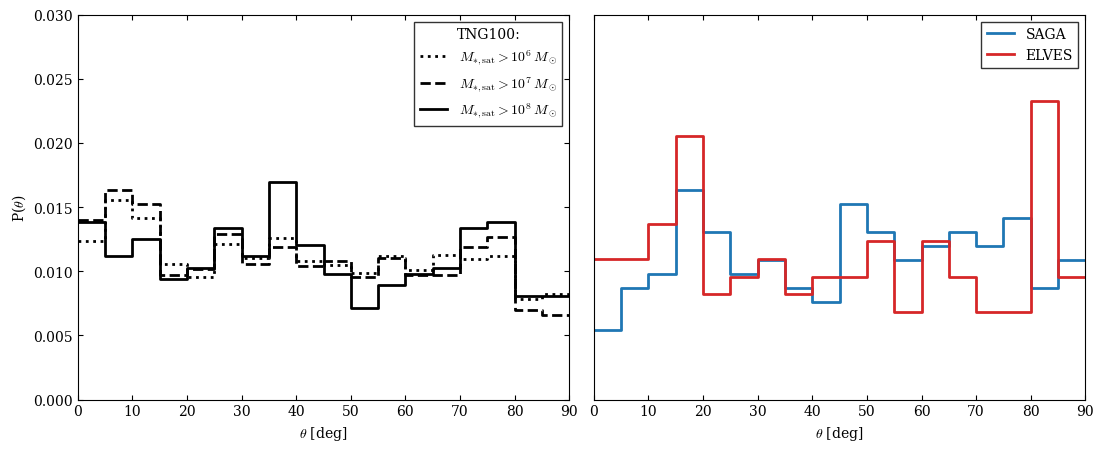

In [10]:
def norm_hist(angles):
    '''Probability density per degree over [0, 90] with N_BINS bins.'''
    c, _ = np.histogram(angles, bins=ANGLE_EDGES)
    return c / c.sum() / (90.0 / N_BINS)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

for cut, ls in zip(list(tng), [':', '--', '-']):
    h = norm_hist(tng[cut]['alpha'])
    axL.step(ANGLE_EDGES, np.r_[h, h[-1]], where='post', color='k', ls=ls, lw=2,
             label=r'$M_{*,\rm sat}>10^{%d}\,M_\odot$' % int(np.log10(float(cut))))

for name, ang, col in [('SAGA', saga_90, SAGA_C), ('ELVES', elves_90, ELVES_C)]:
    h = norm_hist(ang)
    axR.step(ANGLE_EDGES, np.r_[h, h[-1]], where='post', color=col, lw=2, label=name)

for ax in (axL, axR):
    ax.set_xlim(0, 90); ax.set_ylim(0, 0.030)
    ax.set_xlabel(r'$\theta$ [deg]')
    ax.tick_params(which='both', direction='in', top=True, right=True)
axL.set_ylabel(r'P($\theta$)')
axL.legend(title='TNG100:', fancybox=False, edgecolor='k')
axR.legend(fancybox=False, edgecolor='k'); axR.set_yticks([])
plt.subplots_adjust(wspace=0.05); plt.show()

## KS tests

**One-sample** vs a uniform distribution on [0, 90]: is the azimuthal distribution isotropic?
**Two-sample** quenched vs star-forming: are they drawn from the same azimuthal distribution?

In [11]:
print('One-sample KS vs Uniform(0, 90):')
print(f'  SAGA  : {stats.kstest(saga_90,  "uniform", args=(0, 90))}')
print(f'  ELVES : {stats.kstest(elves_90, "uniform", args=(0, 90))}')
for cut in list(tng):
    print(f'  TNG {cut}: {stats.kstest(tng[cut]["alpha"].to_numpy(), "uniform", args=(0, 90))}')

One-sample KS vs Uniform(0, 90):
  SAGA  : KstestResult(statistic=0.05844748725163064, pvalue=0.5363942541253537, statistic_location=14.064621678733715, statistic_sign=-1)
  ELVES : KstestResult(statistic=0.06356524923385029, pvalue=0.5746733666649196, statistic_location=20.169538527857583, statistic_sign=1)
  TNG 1e6: KstestResult(statistic=0.04816142981560978, pvalue=0.0007925842846359214, statistic_location=47.65238386864746, statistic_sign=1)
  TNG 1e7: KstestResult(statistic=0.06406129862742349, pvalue=0.000815957609650575, statistic_location=15.186864075912837, statistic_sign=1)
  TNG 1e8: KstestResult(statistic=0.057497320687205755, pvalue=0.09944345913936015, statistic_location=42.43684828100862, statistic_sign=1)


In [12]:
print('Two-sample KS, quenched vs star-forming azimuthal distribution:')
for name, ang, q in [('SAGA', saga_90, saga_quenched_sel), ('ELVES', elves_90, elves_quenched)]:
    ang = np.asarray(ang); q = np.asarray(q)
    print(f'  {name}: {stats.ks_2samp(ang[q == 1], ang[q == 0])}')
for cut in list(tng):
    d = tng[cut]
    print(f'  TNG {cut}: {stats.ks_2samp(d.alpha[d.quenched == 1], d.alpha[d.quenched == 0])}')

Two-sample KS, quenched vs star-forming azimuthal distribution:
  SAGA: KstestResult(statistic=0.15732256561577884, pvalue=0.31115086712769086, statistic_location=69.08886787710827, statistic_sign=-1)
  ELVES: KstestResult(statistic=0.09652173913043478, pvalue=0.895665744653268, statistic_location=82.32571828368464, statistic_sign=-1)
  TNG 1e6: KstestResult(statistic=0.11611962878913673, pvalue=0.0003001808858158989, statistic_location=40.45944938880661, statistic_sign=-1)
  TNG 1e7: KstestResult(statistic=0.09047325746014818, pvalue=0.04264899276716618, statistic_location=40.81739879936191, statistic_sign=-1)
  TNG 1e8: KstestResult(statistic=0.08717039288956446, pvalue=0.3706618621307305, statistic_location=30.61136569368597, statistic_sign=-1)


## How many satellites are needed to detect anisotropy in TNG?

Subsample the TNG100 azimuthal distribution at fixed N (with replacement, 10^4 trials) and record
the one-sample KS p-value vs uniform. This shows the sample size required for a significant
detection (Section 3 of the draft). Bands are 1/2/3 sigma.

In [13]:
def pvalue_vs_N(angles, Ns, n_boot=10000, seed=42):
    rng = np.random.default_rng(seed)
    angles = np.asarray(angles)
    qs = [(1 - lvl) / 2 * 100 for lvl in (0.6827, 0.9545, 0.9973)]
    med, lo, hi = [], [[], [], []], [[], [], []]
    for N in Ns:
        pv = np.array([stats.kstest(rng.choice(angles, size=N, replace=True),
                                    'uniform', args=(0, 90)).pvalue for _ in range(n_boot)])
        med.append(np.median(pv))
        for j, ql in enumerate(qs):
            lo[j].append(np.percentile(pv, ql)); hi[j].append(np.percentile(pv, 100 - ql))
    return np.array(med), [np.array(x) for x in lo], [np.array(x) for x in hi]

Ns = np.arange(10, 2000, 100)
pv = {cut: pvalue_vs_N(tng[cut]['alpha'].to_numpy(), Ns) for cut in list(tng)}

KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
titles = {k: r'$M_{*,\rm sat}/M_\odot>10^{%d}$' % int(np.log10(float(k))) for k in tng}
for a, cut in zip(ax, list(tng)):
    med, lo, hi = pv[cut]
    for j in range(3):
        a.fill_between(Ns, lo[j], hi[j], color='gray', alpha=0.4)
    a.plot(Ns, med, color='k', lw=2)
    a.axhline(0.10, color='r', ls='--', lw=1); a.axhline(0.05, color='r', ls='--', lw=1)
    a.set_yscale('log'); a.set_xlim(10, 1500); a.set_ylim(1e-12, 1e1)
    a.set_xlabel(r'$N_{\rm sat}$'); a.set_title(titles[cut])
    a.grid(True, which='both', alpha=0.3, ls='--')
    a.tick_params(which='both', direction='in', top=True, right=True)
ax[0].set_ylabel('one-sample KS p-value')
plt.subplots_adjust(wspace=0.05); plt.show()

## Quench fraction vs angle: bootstrap + sinusoid MCMC fit

A single, uniform bootstrap is used for every dataset (this replaces the two slightly different
bootstrap routines in the original notebook): resample the (angle, quenched) pairs with
replacement N times and take the binned-mean quench fraction per angle bin.

The model is `f_q(theta) = a + b*cos(2 theta)` with a Gaussian jitter term `exp(f)` added in
quadrature to the per-bin error (Martín-Navarro+ 2021, their Section 2.1). `b = 0` is a constant
(no anisotropy).

In [14]:
def bootstrap_fq(angle, quenched, N=10000, seed=0):
    '''Binned-mean quench fraction per angle bin, with bootstrap mean and 1-sigma error.'''
    rng = np.random.default_rng(seed)
    angle = np.asarray(angle); quenched = np.asarray(quenched, dtype=float)
    n = len(angle)
    boot = np.full((N, N_BINS), np.nan)
    bin_idx = np.digitize(angle, ANGLE_EDGES) - 1
    for i in range(N):
        s = rng.integers(0, n, n)
        bi, qi = bin_idx[s], quenched[s]
        for j in range(N_BINS):
            m = bi == j
            if m.any():
                boot[i, j] = qi[m].mean()
    return np.nanmean(boot, axis=0), np.nanstd(boot, axis=0)

fq = {}   # dataset -> (mean, std) over ANGLE_CENTERS
fq['saga']  = bootstrap_fq(saga_90, saga_quenched_sel)
fq['elves'] = bootstrap_fq(elves_90, elves_quenched)
for cut in list(tng):
    fq[cut] = bootstrap_fq(tng[cut]['alpha'].to_numpy(), tng[cut]['quenched'].to_numpy())

In [15]:
def log_likelihood(theta, x, y, sigma):
    a, b, f = theta
    s = sigma ** 2 + np.exp(f) ** 2
    model = a + b * np.cos(2 * np.radians(x))
    return -0.5 * np.sum((y - model) ** 2 / s + np.log(2 * np.pi * s))

def log_prior(theta):
    a, b, f = theta
    return 0.0 if (0 < a < 1 and -1 < b < 1 and -10 < f < 2) else -np.inf

def log_prob(theta, x, y, sigma):
    lp = log_prior(theta)
    return lp + log_likelihood(theta, x, y, sigma) if np.isfinite(lp) else -np.inf

def fit_sinusoid(mean, std, n_walkers=20, n_steps=10000, burn=1000, seed=0):
    '''MCMC fit of a + b*cos(2 theta); returns (params_mean, params_std).'''
    np.random.seed(seed)
    ok = np.isfinite(mean) & np.isfinite(std) & (std > 0)
    p0 = np.array([0.7, 0.025, -3.0]) + 1e-2 * np.random.randn(n_walkers, 3)
    sampler = emcee.EnsembleSampler(n_walkers, 3, log_prob,
                                    args=(ANGLE_CENTERS[ok], mean[ok], std[ok]))
    sampler.run_mcmc(p0, n_steps, progress=False)
    chain = sampler.get_chain(discard=burn, flat=True)
    return chain.mean(axis=0), chain.std(axis=0)

params = {k: fit_sinusoid(*fq[k]) for k in fq}
for k, (p, e) in params.items():
    print(f'{k:>5}:  a = {p[0]:.3f} +/- {e[0]:.3f}   b = {p[1]:+.3f} +/- {e[1]:.3f}   '
          f'|b|/sigma_b = {abs(p[1] / e[1]):.2f}')

 saga:  a = 0.220 +/- 0.035   b = +0.004 +/- 0.054   |b|/sigma_b = 0.08
elves:  a = 0.686 +/- 0.052   b = +0.039 +/- 0.069   |b|/sigma_b = 0.57
  1e6:  a = 0.749 +/- 0.011   b = -0.063 +/- 0.015   |b|/sigma_b = 4.19
  1e7:  a = 0.587 +/- 0.016   b = -0.056 +/- 0.023   |b|/sigma_b = 2.42
  1e8:  a = 0.377 +/- 0.024   b = -0.033 +/- 0.033   |b|/sigma_b = 1.00


## Figure 1 (bottom) — quench fraction vs angle with sinusoid fits

Left: TNG100 (three mass cuts). Right: SAGA and ELVES. Shaded bands are the 16-84th percentile of
the sinusoid model from the MCMC posterior.

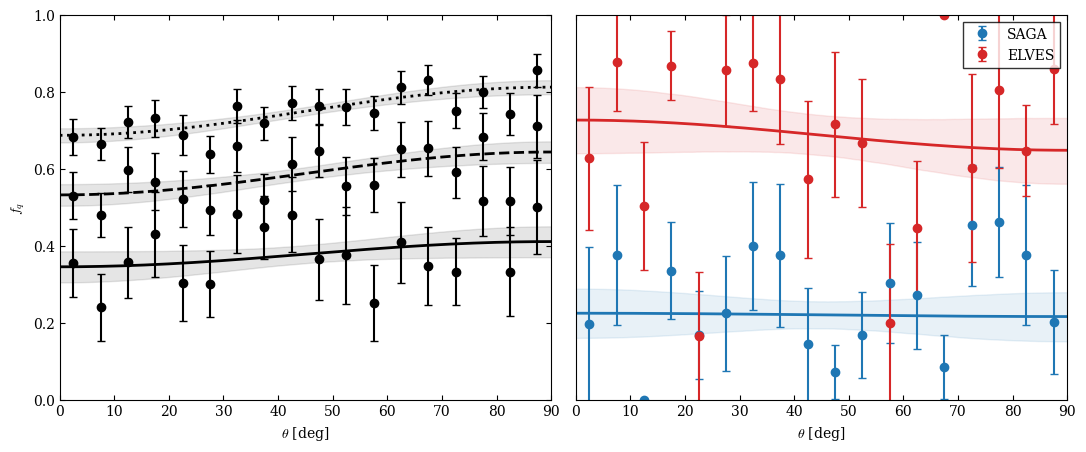

In [16]:
def model_band(p, e, n_mc=10000, seed=0):
    rng = np.random.default_rng(seed)
    x = np.linspace(0, np.pi / 2, 400)
    a = rng.normal(p[0], e[0], n_mc); b = rng.normal(p[1], e[1], n_mc)
    y = a[:, None] + b[:, None] * np.cos(2 * x)[None, :]
    xdeg = np.degrees(x)
    return xdeg, (a.mean() + b.mean() * np.cos(2 * x)), np.percentile(y, 16, 0), np.percentile(y, 84, 0)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

for cut, ls in zip(list(tng), [':', '--', '-']):
    m, s = fq[cut]
    axL.errorbar(ANGLE_CENTERS, m, yerr=s, fmt='o', color='k', capsize=3)
    xdeg, ymed, ylo, yhi = model_band(*params[cut])
    axL.plot(xdeg, ymed, color='k', lw=2, ls=ls)
    axL.fill_between(xdeg, ylo, yhi, color='k', alpha=0.1)

for name, key, col in [('SAGA', 'saga', SAGA_C), ('ELVES', 'elves', ELVES_C)]:
    m, s = fq[key]
    axR.errorbar(ANGLE_CENTERS, m, yerr=s, fmt='o', color=col, capsize=3, label=name)
    xdeg, ymed, ylo, yhi = model_band(*params[key])
    axR.plot(xdeg, ymed, color=col, lw=2)
    axR.fill_between(xdeg, ylo, yhi, color=col, alpha=0.1)

for ax in (axL, axR):
    ax.set_xlim(0, 90); ax.set_ylim(0, 1); ax.set_xlabel(r'$\theta$ [deg]')
    ax.tick_params(which='both', direction='in', top=True, right=True)
axL.set_ylabel(r'$f_q$'); axR.legend(fancybox=False, edgecolor='k'); axR.set_yticks([])
plt.subplots_adjust(wspace=0.05); plt.show()

## Sinusoid vs constant: BIC / AIC and amplitude significance

Is the sinusoid a better description than a constant (the mean quench fraction)? We compare BIC
and AIC for the two models. A useful rule of thumb: Delta(BIC) > 10 is strong evidence.

> Caveat: the jitter parameter `f` is a third fitted parameter; the information criteria below
> count `k = 2` for the sinusoid (a, b) and `k = 1` for the constant, treating `f` as a nuisance
> term as in Martín-Navarro+ 2021. The amplitude significance `|b|/sigma_b` is reported alongside.

In [17]:
def info_criteria(x, y, yerr, p):
    ok = np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)
    x, y, yerr = x[ok], y[ok], yerr[ok]
    n = len(y)
    a, b, f = p
    resid_sin = y - (a + b * np.cos(2 * np.radians(x)))
    logL_sin  = -0.5 * np.sum((resid_sin / yerr) ** 2 + np.log(2 * np.pi * yerr ** 2))
    resid_con = y - np.mean(y)
    logL_con  = -0.5 * np.sum((resid_con / yerr) ** 2 + np.log(2 * np.pi * yerr ** 2))
    bic_sin = 2 * np.log(n) - 2 * logL_sin;  aic_sin = 2 * 2 - 2 * logL_sin
    bic_con = 1 * np.log(n) - 2 * logL_con;  aic_con = 2 * 1 - 2 * logL_con
    return bic_sin, bic_con, aic_sin, aic_con

for key in ['elves', 'saga'] + list(tng):
    m, s = fq[key]; p, e = params[key]
    bs, bc, as_, ac = info_criteria(ANGLE_CENTERS, m, s, p)
    pref_bic = 'sinusoid' if bs < bc else 'constant'
    print(f'{key:>5}: dBIC = {abs(bs - bc):5.2f} ({pref_bic} preferred)  '
          f'dAIC = {abs(as_ - ac):5.2f}   |b|/sigma_b = {abs(p[1] / e[1]):.2f}')

elves: dBIC =  0.21 (sinusoid preferred)  dAIC =  1.05   |b|/sigma_b = 0.57
 saga: dBIC =  0.57 (sinusoid preferred)  dAIC =  1.40   |b|/sigma_b = 0.08
  1e6: dBIC = 15.27 (sinusoid preferred)  dAIC = 16.16   |b|/sigma_b = 4.19
  1e7: dBIC =  3.38 (sinusoid preferred)  dAIC =  4.27   |b|/sigma_b = 2.42
  1e8: dBIC =  1.82 (constant preferred)  dAIC =  0.93   |b|/sigma_b = 1.00


## Alignment effect size  <cos 2 theta>

A single number summarizing alignment: `<cos 2 theta>` > 0 means an excess near the major axis.
95% confidence intervals come from a simple bootstrap.

In [18]:
def cos2theta_ci(theta_deg, B=5000, seed=0):
    rng = np.random.default_rng(seed)
    t = np.radians(np.asarray(theta_deg))
    A = np.mean(np.cos(2 * t))
    boot = [np.mean(np.cos(2 * rng.choice(t, size=len(t), replace=True))) for _ in range(B)]
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return A, lo, hi

for name, ang in [('SAGA', saga_90), ('ELVES', elves_90),
                  (f'TNG {list(tng)[0]}', tng[list(tng)[0]]['alpha']),
                  (f'TNG {list(tng)[-1]}', tng[list(tng)[-1]]['alpha'])]:
    A, lo, hi = cos2theta_ci(ang)
    print(f'{name:>8}: <cos 2theta> = {A:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]')

    SAGA: <cos 2theta> = -0.0473  95% CI [-0.1499, +0.0541]
   ELVES: <cos 2theta> = +0.0244  95% CI [-0.0924, +0.1400]
 TNG 1e6: <cos 2theta> = +0.0732  95% CI [+0.0390, +0.1065]
 TNG 1e8: <cos 2theta> = +0.0502  95% CI [-0.0159, +0.1152]


## Appendix — projected vs true azimuthal angle

A geometric illustration (not used in Figure 1): for satellites isotropically distributed in a
sphere, how much does projection distort the azimuthal angle? Relevant to the discussion of why
the projected signal is suppressed relative to the 3D signal (Martín-Navarro+ 2021).

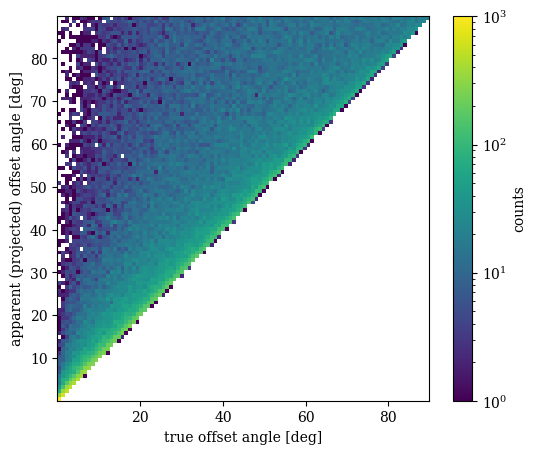

fraction with |projected - true| <= 20 deg: 77.2%


In [19]:
rng = np.random.default_rng(0)
N = 100000
phi = 2 * np.pi * rng.random(N)
costheta = 2 * rng.random(N) - 1
theta = np.arccos(costheta)
r = rng.random(N) ** (1 / 3)
x = r * np.sin(theta) * np.cos(phi); y = r * np.sin(theta) * np.sin(phi); z = r * np.cos(theta)

true_angle = np.degrees(np.arctan(np.abs(z) / np.sqrt(x**2 + y**2)))
proj_angle = np.degrees(np.arctan(np.abs(z) / np.abs(x)))

plt.figure(figsize=(6, 5))
plt.hist2d(true_angle, proj_angle, bins=100, norm=mpl.colors.LogNorm())
plt.xlabel('true offset angle [deg]'); plt.ylabel('apparent (projected) offset angle [deg]')
plt.colorbar(label='counts'); plt.show()

frac = np.mean(np.abs(proj_angle - true_angle) <= 20)
print(f'fraction with |projected - true| <= 20 deg: {100 * frac:.1f}%')